PACKAGE IMPORTS

In [195]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ASSISTANT FUNCTIONS

In [196]:
def better_df_info(df):
    # HEADER
    print(100*'-')
    print('Better DataFrame Info:'.center(100))

    # SHAPE
    print('\033[4m'+'Shape:'+'\033[0m')
    print(f'Row Count:      {df.shape[0]:,}')
    print(f'Columnn Count:  {df.shape[1]:,}','\n')

    # DATA TYPES & ZERO/NULL VALUES
    print('\033[4m'+'Data Types & Missing Values:'+'\033[0m')
    num_cols = df.select_dtypes(include='number').columns
    zn_df = df.isna() #.copy()
    zn_df[num_cols] = zn_df[num_cols] | (df[num_cols] == 0)
    df_mv = pd.DataFrame({
        'Data Type': df.dtypes,
        'Distinct (#)': df.nunique(),
        'Zero/Null (#)': zn_df.sum(),
        'Zero/Null (%)': zn_df.sum() / len(df) * 100,
        'Non-Zero/Null (#)': (~zn_df).sum(),
        'Non-Zero/Null (%)': (~zn_df).sum() / len(df) * 100})
    df_mv['Distinct (#)'] = df_mv['Distinct (#)'].map('{:,}'.format)
    df_mv['Zero/Null (#)'] = df_mv['Zero/Null (#)'].map('{:,}'.format)
    df_mv['Zero/Null (%)'] = df_mv['Zero/Null (%)'].map('{:.2f}%'.format)
    df_mv['Non-Zero/Null (#)'] = df_mv['Non-Zero/Null (#)'].map('{:,}'.format)
    df_mv['Non-Zero/Null (%)'] = df_mv['Non-Zero/Null (%)'].map('{:.2f}%'.format)
    display(df_mv)

    # FOOTER
    print(100*'-')

def draw_histogram(df,col):
    # BIN DETERMINATIONS
    if df[col].dtype == int or df[col].dtype == float:
        # FREEDMAN-DRACONIS RULE
        data = df[col]
        range = data.max() - data.min()
        iqr = np.percentile(df[col],75) - np.percentile(df[col],25)
        n = data.size
        width = (2 * iqr) / n**(1/3)
        nBins = math.ceil(range / width)
        print('Range = ',range,'IQR = ',iqr,'N = ',n,'Width = ',width,'nBins = ',nBins)
    elif df[col].dtype == object:
        nBins = df[col].nunique()
    
    # PLOT RESULTS
    plt.figure(figsize=(5,2))
    plt.hist(df[col], bins=nBins, color='teal', edgecolor='black')
    plt.title('Distribution of '+col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    # print(list(df[col].unique()),"\n")

DATA PREPARATION

In [197]:
# DATA IMPORT
url = 'https://raw.githubusercontent.com/mnorton365/Python/refs/heads/main/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(url)

# INITIAL VISUALIZATIONS
display(df.head())
better_df_info(df)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,.,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24,never smoked,1


----------------------------------------------------------------------------------------------------
                                       Better DataFrame Info:                                       
Shape:
Row Count:      5,110
Columnn Count:  12 

Data Types & Missing Values:


,Data Type,Distinct (#),Zero/Null (#),Zero/Null (%),Non-Zero/Null (#),Non-Zero/Null (%)
id,int64,"5,110",0,0.00%,"5,110",100.00%
gender,object,3,0,0.00%,"5,110",100.00%
age,float64,104,0,0.00%,"5,110",100.00%
hypertension,int64,2,"4,612",90.25%,498,9.75%
heart_disease,int64,2,"4,834",94.60%,276,5.40%
ever_married,object,2,0,0.00%,"5,110",100.00%
work_type,object,5,0,0.00%,"5,110",100.00%
Residence_type,object,2,0,0.00%,"5,110",100.00%
avg_glucose_level,float64,"3,979",0,0.00%,"5,110",100.00%
bmi,object,419,0,0.00%,"5,110",100.00%


----------------------------------------------------------------------------------------------------


In [ ]:
# ADJUSTING DATA TYPES
df['id'] = df['id'].astype(str)
df['bmi'] = pd.to_numeric(df['bmi'],errors='coerce').fillna(0)

for col in df:
    draw_histogram(df,col)

----------------------------------------------------------------------------------------------------
                                       Better DataFrame Info:                                       
Shape:
Row Count:      5,110
Columnn Count:  12 

Data Types & Missing Values:


,Data Type,Distinct (#),Zero/Null (#),Zero/Null (%),Non-Zero/Null (#),Non-Zero/Null (%)
id,object,"5,110",0,0.00%,"5,110",100.00%
gender,object,3,0,0.00%,"5,110",100.00%
age,float64,104,0,0.00%,"5,110",100.00%
hypertension,int64,2,"4,612",90.25%,498,9.75%
heart_disease,int64,2,"4,834",94.60%,276,5.40%
ever_married,object,2,0,0.00%,"5,110",100.00%
work_type,object,5,0,0.00%,"5,110",100.00%
Residence_type,object,2,0,0.00%,"5,110",100.00%
avg_glucose_level,float64,"3,979",0,0.00%,"5,110",100.00%
bmi,float64,419,201,3.93%,"4,909",96.07%


----------------------------------------------------------------------------------------------------
201


Range =  97.6 IQR =  9.899999999999999 N =  5110 Width =  1.14954212390826 nBins =  85


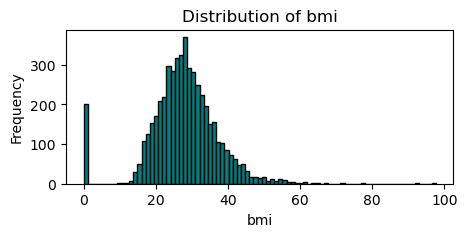

Range =  81.92 IQR =  36.0 N =  5110 Width =  4.180153177848219 nBins =  20


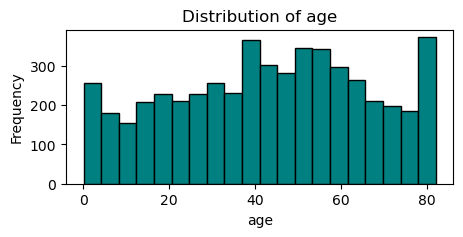

In [199]:
draw_histogram(df,'bmi')
draw_histogram(df,'age')